# Multimodal Mineral Classification System
## Deep Learning for Geoacoustic Traceability

---

**Project:** AI-Powered Mineral Identification and Traceability

**Objective:** Train a multimodal deep learning model to classify minerals (Gold, Chalcopyrite, Hematite) using three data modalities:
-  **Image features** (ResNet18-based CNN)
-  **Audio features** (MFCC spectrograms)
-  **Chemical composition** (Au, Cu, Fe, S, O)



---
#  Step 1: Import Required Libraries
Import all necessary packages for data processing, deep learning, and visualization.

In [ ]:
# Core Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, 
    precision_recall_fscore_support,
    confusion_matrix, 
    ConfusionMatrixDisplay,
    classification_report
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# PyTorch & Deep Learning
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms as T

# Custom Modules
from multimodal_dataset import MultiModalDataset
from multimodal_model import MultiModalNet

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)
torch.manual_seed(42)

print(" All libraries imported successfully!")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

✅ All libraries imported successfully!
PyTorch Version: 2.10.0+cpu
CUDA Available: False


---
#  Step 2: Load and Explore Dataset
Load training and test CSV files and preview the data structure.

In [ ]:
# Load CSV files
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"\n Training samples: {len(train_df)}")
print(f"📁 Test samples: {len(test_df)}")
print(f"📁 Total samples: {len(train_df) + len(test_df)}")
print(f"\n📋 Columns: {list(train_df.columns)}")
print(f"\n🔍 Data types:\n{train_df.dtypes}")

DATASET OVERVIEW

📁 Training samples: 443
📁 Test samples: 261
📁 Total samples: 704

📋 Columns: ['sample_id', 'site', 'mineral', 'image_path', 'audio_path', 'Au', 'Cu', 'Fe', 'S', 'O']

🔍 Data types:
sample_id       str
site            str
mineral         str
image_path      str
audio_path      str
Au            int64
Cu            int64
Fe            int64
S             int64
O             int64
dtype: object


### 2.1 Preview First 5 Training Samples

In [3]:
print("\n" + "=" * 80)
print("FIRST 5 TRAINING SAMPLES")
print("=" * 80 + "\n")
train_df.head()


FIRST 5 TRAINING SAMPLES



,sample_id,site,mineral,image_path,audio_path,Au,Cu,Fe,S,O
0,S00001,Kapoeta_East,gold,images\Kapoeta_East\gold\001853200175794288911...,audio\Kapoeta_East\gold\Kapoeta_East_gold_003.wav,1,0,0,0,0
1,S00002,Kapoeta_East,gold,images\Kapoeta_East\gold\002916000176171267039...,audio\Kapoeta_East\gold\Kapoeta_East_gold_004.wav,1,0,0,0,0
2,S00003,Kapoeta_East,gold,images\Kapoeta_East\gold\004402500176376614182...,audio\Kapoeta_East\gold\Kapoeta_East_gold_001.wav,1,0,0,0,0
3,S00004,Kapoeta_East,gold,images\Kapoeta_East\gold\005909400175553231399...,audio\Kapoeta_East\gold\Kapoeta_East_gold_003.wav,1,0,0,0,0
4,S00005,Kapoeta_East,gold,images\Kapoeta_East\gold\006046500176336546449...,audio\Kapoeta_East\gold\Kapoeta_East_gold_007.wav,1,0,0,0,0


### 2.2 Class Distribution Analysis

In [ ]:
# Analyze class distribution
train_counts = train_df['mineral'].value_counts()
test_counts = test_df['mineral'].value_counts()

print("=" * 80)
print("CLASS DISTRIBUTION")
print("=" * 80)
print("\n Training Set:")
for mineral, count in train_counts.items():
    percentage = (count / len(train_df)) * 100
    print(f"   {mineral:15s}: {count:3d} samples ({percentage:5.2f}%)")

print("\n Test Set:")
for mineral, count in test_counts.items():
    percentage = (count / len(test_df)) * 100
    print(f"   {mineral:15s}: {count:3d} samples ({percentage:5.2f}%)")

# Check for class imbalance
imbalance_ratio = train_counts.max() / train_counts.min()
print(f"\n Imbalance Ratio: {imbalance_ratio:.2f}x")
if imbalance_ratio > 1.5:
    print("     WARNING: Significant class imbalance detected!")
    print("    Solution: Using class weights in loss function")
else:
    print("    Classes are reasonably balanced")

CLASS DISTRIBUTION

📊 Training Set:
   gold           : 163 samples (36.79%)
   chalcopyrite   : 150 samples (33.86%)
   hematite       : 130 samples (29.35%)

📊 Test Set:
   gold           :  98 samples (37.55%)
   chalcopyrite   :  98 samples (37.55%)
   hematite       :  65 samples (24.90%)

⚖️  Imbalance Ratio: 1.25x
   ✅ Classes are reasonably balanced


### 2.3 Chemical Feature Statistics

In [ ]:
# Analyze chemical features
chem_features = ['Au', 'Cu', 'Fe', 'S', 'O']

print("=" * 80)
print("CHEMICAL FEATURES ANALYSIS")
print("=" * 80)
print("\n Feature Ranges (Training Data):")
print(f"\n{'Feature':<10} {'Min':<10} {'Max':<10} {'Mean':<10} {'Std':<10}")
print("-" * 50)

for feature in chem_features:
    print(f"{feature:<10} {train_df[feature].min():<10.2f} {train_df[feature].max():<10.2f} "
          f"{train_df[feature].mean():<10.2f} {train_df[feature].std():<10.2f}")

print("\n Note: Features will be normalized using StandardScaler to handle different scales.")

CHEMICAL FEATURES ANALYSIS

🧪 Feature Ranges (Training Data):

Feature    Min        Max        Mean       Std       
--------------------------------------------------
Au         0.00       1.00       0.37       0.48      
Cu         0.00       1.00       0.34       0.47      
Fe         0.00       2.00       0.93       0.81      
S          0.00       2.00       0.68       0.95      
O          0.00       3.00       0.88       1.37      

💡 Note: Features will be normalized using StandardScaler to handle different scales.


---
#  Step 3: Data Preprocessing & Augmentation
Define image transformations with augmentation for training and standard transforms for testing.

In [6]:
# Training transforms WITH data augmentation
train_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),                    # Random horizontal flip
    T.RandomRotation(degrees=15),                      # Random rotation ±15°
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),  # Color augmentation
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],           # ImageNet normalization
                std=[0.229, 0.224, 0.225])
])

# Test transforms WITHOUT augmentation
test_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

print("✅ Image transforms defined successfully!")
print("\n📸 Training Augmentations:")
print("   - Random Horizontal Flip (50% probability)")
print("   - Random Rotation (±15 degrees)")
print("   - Color Jitter (brightness, contrast, saturation)")
print("   - ImageNet Normalization")
print("\n📸 Test Preprocessing:")
print("   - Resize to 224x224")
print("   - ImageNet Normalization (no augmentation)")

✅ Image transforms defined successfully!

📸 Training Augmentations:
   - Random Horizontal Flip (50% probability)
   - Random Rotation (±15 degrees)
   - Color Jitter (brightness, contrast, saturation)
   - ImageNet Normalization

📸 Test Preprocessing:
   - Resize to 224x224
   - ImageNet Normalization (no augmentation)


---
#  Step 4: Create Dataset and DataLoaders
Initialize PyTorch datasets and dataloaders with proper preprocessing.

In [ ]:
# Create datasets (chemical normalization happens in MultiModalDataset class)
train_dataset = MultiModalDataset(
    csv_file='train.csv',
    transform=train_transform
)

test_dataset = MultiModalDataset(
    csv_file='test.csv',
    transform=test_transform
)

# Create dataloaders
batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(" Datasets and DataLoaders created successfully!")
print(f"\n Training batches: {len(train_loader)}")
print(f" Test batches: {len(test_loader)}")
print(f" Batch size: {batch_size}")

✅ Chemical features normalized for train.csv
✅ Chemical features normalized for test.csv
✅ Datasets and DataLoaders created successfully!

📊 Training batches: 56
📊 Test batches: 33
📊 Batch size: 8


---
#  Step 5: Handle Class Imbalance
Compute class weights to give more importance to underrepresented classes during training.

In [8]:
# Extract all training labels
train_labels = []
for _, _, _, label in train_dataset:
    train_labels.append(label)
train_labels = np.array(train_labels)

# Compute balanced class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Convert to tensor
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

# Display weights
class_names = ['Gold', 'Chalcopyrite', 'Hematite']
print("=" * 80)
print("CLASS WEIGHTS FOR BALANCED TRAINING")
print("=" * 80)
for i, (name, weight) in enumerate(zip(class_names, class_weights)):
    print(f"\n{name:15s} (class {i}): {weight:.4f}")
    if weight > 1.0:
        print(f"   ↑ Higher weight = Model will focus MORE on this class")
    else:
        print(f"   → Standard weight")

print(f"\n💡 Weights will be used in CrossEntropyLoss to handle class imbalance.")

c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CLASS WEIGHTS FOR BALANCED TRAINING

Gold            (class 0): 0.9059
   → Standard weight

Chalcopyrite    (class 1): 0.9844
   → Standard weight

Hematite        (class 2): 1.1359
   ↑ Higher weight = Model will focus MORE on this class

💡 Weights will be used in CrossEntropyLoss to handle class imbalance.


---
#  Step 6: Initialize Model Architecture
Create the multimodal neural network with three encoders (Image, Audio, Chemical).

In [9]:
# Initialize model
num_classes = 3
model = MultiModalNet(num_classes=num_classes).to(device)

print("=" * 80)
print("MODEL ARCHITECTURE")
print("=" * 80)
print("\n🏗️  MultiModalNet Components:")
print("\n1️⃣  Image Encoder (ResNet18):")
print("   - Input: RGB images (224×224)")
print("   - Output: 128-dimensional feature vector")
print("\n2️⃣  Audio Encoder (CNN):")
print("   - Input: MFCC spectrograms (20×T)")
print("   - Output: 64-dimensional feature vector")
print("\n3️⃣  Chemical Encoder (MLP):")
print("   - Input: 5 chemical features (Au, Cu, Fe, S, O) - NORMALIZED")
print("   - Output: 32-dimensional feature vector")
print("\n4️⃣  Fusion & Classification:")
print("   - Concatenate: 128 + 64 + 32 = 224 dimensions")
print("   - Fully connected layers with dropout (0.3)")
print("   - Output: 3-class probabilities (Gold, Chalcopyrite, Hematite)")

# Model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n📊 Model Statistics:")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Device: {device}")

MODEL ARCHITECTURE

🏗️  MultiModalNet Components:

1️⃣  Image Encoder (ResNet18):
   - Input: RGB images (224×224)
   - Output: 128-dimensional feature vector

2️⃣  Audio Encoder (CNN):
   - Input: MFCC spectrograms (20×T)
   - Output: 64-dimensional feature vector

3️⃣  Chemical Encoder (MLP):
   - Input: 5 chemical features (Au, Cu, Fe, S, O) - NORMALIZED
   - Output: 32-dimensional feature vector

4️⃣  Fusion & Classification:
   - Concatenate: 128 + 64 + 32 = 224 dimensions
   - Fully connected layers with dropout (0.3)
   - Output: 3-class probabilities (Gold, Chalcopyrite, Hematite)

📊 Model Statistics:
   Total parameters: 11,279,523
   Trainable parameters: 11,279,523
   Device: cpu


---
# ⚙️ Step 7: Training Configuration
Set up loss function, optimizer, and training hyperparameters.

In [10]:
# Training hyperparameters
num_epochs = 15
learning_rate = 1e-4

# Loss function with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print("=" * 80)
print("TRAINING CONFIGURATION")
print("=" * 80)
print(f"\n📋 Hyperparameters:")
print(f"   Number of epochs: {num_epochs}")
print(f"   Learning rate: {learning_rate}")
print(f"   Batch size: {batch_size}")
print(f"   Optimizer: Adam")
print(f"   Loss function: CrossEntropyLoss (with class weights)")
print(f"\n✅ Ready to start training!")

TRAINING CONFIGURATION

📋 Hyperparameters:
   Number of epochs: 15
   Learning rate: 0.0001
   Batch size: 8
   Optimizer: Adam
   Loss function: CrossEntropyLoss (with class weights)

✅ Ready to start training!


---
# 🎯 Step 8: Define Training & Evaluation Functions

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Train model for one epoch."""
    model.train()
    total_loss = 0.0
    
    for images, audios, chemicals, labels in loader:
        # Move data to device
        images = images.to(device)
        audios = audios.to(device)
        chemicals = chemicals.to(device)
        labels = labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images, audios, chemicals)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)


def evaluate(model, loader, device):
    """Evaluate model on validation/test set."""
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, audios, chemicals, labels in loader:
            # Move data to device
            images = images.to(device)
            audios = audios.to(device)
            chemicals = chemicals.to(device)
            labels = labels.to(device)
            
            # Forward pass
            outputs = model(images, audios, chemicals)
            predictions = outputs.argmax(dim=1)
            
            # Compute accuracy
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    
    return correct / total

print("✅ Training and evaluation functions defined!")

✅ Training and evaluation functions defined!


---
# 🚀 Step 9: Train the Model
Execute the training loop and monitor progress.

In [12]:
print("=" * 80)
print("TRAINING STARTED")
print("=" * 80)
print(f"\nEpoch | Train Loss | Test Accuracy")
print("-" * 40)

for epoch in range(num_epochs):
    # Train one epoch
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    
    # Evaluate on test set
    test_acc = evaluate(model, test_loader, device)
    
    # Print progress
    print(f"{epoch+1:5d} | {train_loss:10.4f} | {test_acc:13.4f} ({test_acc*100:.2f}%)")

print("\n" + "=" * 80)
print("✅ TRAINING COMPLETED!")
print("=" * 80)
print(f"\nFinal Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

TRAINING STARTED

Epoch | Train Loss | Test Accuracy
----------------------------------------
    1 |     0.9127 |        0.6130 (61.30%)
    2 |     0.6057 |        0.6475 (64.75%)
    3 |     0.4367 |        0.7011 (70.11%)
    4 |     0.3184 |        0.7280 (72.80%)
    5 |     0.2411 |        0.7088 (70.88%)
    6 |     0.1976 |        0.7471 (74.71%)
    7 |     0.1803 |        0.8046 (80.46%)
    8 |     0.1089 |        0.8084 (80.84%)
    9 |     0.1042 |        0.8199 (81.99%)
   10 |     0.0940 |        0.7969 (79.69%)
   11 |     0.0380 |        0.8582 (85.82%)
   12 |     0.0351 |        0.8123 (81.23%)
   13 |     0.0232 |        0.8046 (80.46%)
   14 |     0.0422 |        0.8199 (81.99%)
   15 |     0.0489 |        0.9234 (92.34%)

✅ TRAINING COMPLETED!

Final Test Accuracy: 0.9234 (92.34%)


---
# 💾 Step 10: Save Trained Model
Persist the model weights for future inference.

In [13]:
# Save model
model_path = 'multimodal_model.pt'
torch.save(model.state_dict(), model_path)

# Verify file size
model_size_mb = os.path.getsize(model_path) / (1024 * 1024)

print("=" * 80)
print("MODEL SAVED")
print("=" * 80)
print(f"\n📁 File: {model_path}")
print(f"📊 Size: {model_size_mb:.2f} MB")
print(f"✅ Model weights saved successfully!")

MODEL SAVED

📁 File: multimodal_model.pt
📊 Size: 43.11 MB
✅ Model weights saved successfully!


---
# 📊 Step 11: Comprehensive Model Evaluation
Generate detailed metrics and confusion matrix.

### 11.1 Generate Predictions

In [14]:
# Get predictions for entire test set
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, audios, chemicals, labels in test_loader:
        images = images.to(device)
        audios = audios.to(device)
        chemicals = chemicals.to(device)
        
        outputs = model(images, audios, chemicals)
        predictions = outputs.argmax(dim=1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("✅ Predictions generated for all test samples!")

✅ Predictions generated for all test samples!


### 11.2 Confusion Matrix

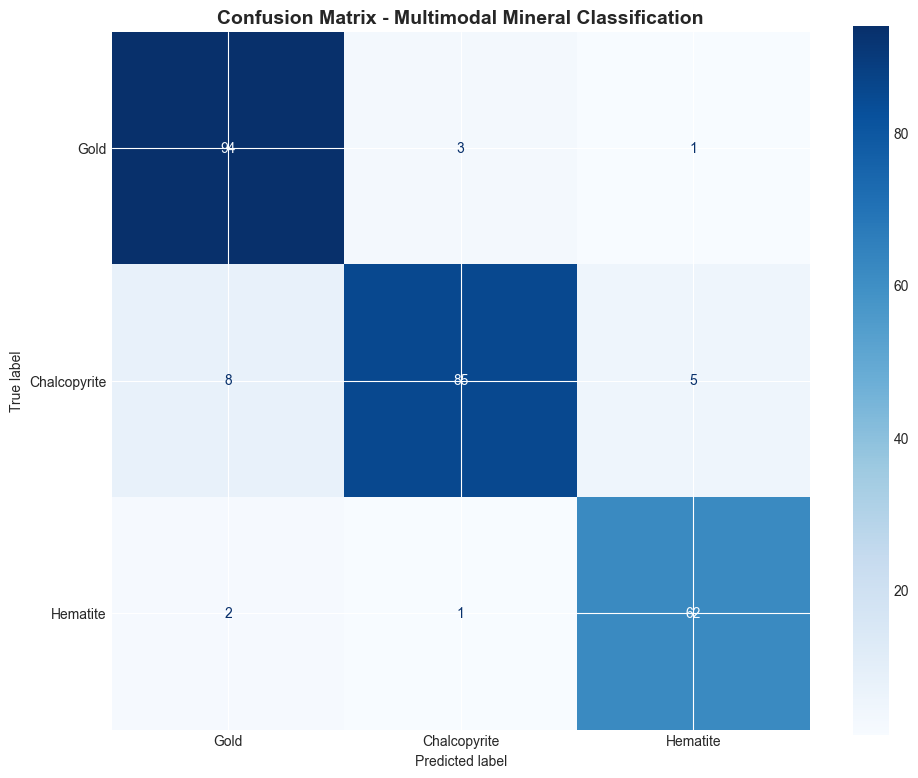


📊 Confusion Matrix Analysis:
   Gold: 94/98 correctly classified (95.9%)
   Chalcopyrite: 85/98 correctly classified (86.7%)
   Hematite: 62/65 correctly classified (95.4%)


In [15]:
# Compute and plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix - Multimodal Mineral Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Confusion Matrix Analysis:")
for i, mineral in enumerate(class_names):
    true_positives = cm[i, i]
    total = cm[i].sum()
    accuracy = (true_positives / total) * 100 if total > 0 else 0
    print(f"   {mineral}: {true_positives}/{total} correctly classified ({accuracy:.1f}%)")

### 11.3 Detailed Metrics (Accuracy, Precision, Recall, F1)

In [16]:
# Calculate comprehensive metrics
accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, average=None, zero_division=0
)

# Macro-averaged metrics
macro_precision = precision.mean()
macro_recall = recall.mean()
macro_f1 = f1.mean()

# Calculate FPR and Specificity per class
fpr_per_class = []
specificity_per_class = []

for i in range(num_classes):
    tn = ((y_true != i) & (y_pred != i)).sum()
    fp = ((y_true != i) & (y_pred == i)).sum()
    
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    
    fpr_per_class.append(fpr)
    specificity_per_class.append(specificity)

macro_fpr = np.mean(fpr_per_class)
macro_specificity = np.mean(specificity_per_class)

# Print results
print("=" * 90)
print("MODEL EVALUATION METRICS")
print("=" * 90)

print("\n📊 OVERALL METRICS:")
print(f"   Accuracy:          {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   Macro Precision:   {macro_precision:.4f} ({macro_precision*100:.2f}%)")
print(f"   Macro Recall:      {macro_recall:.4f} ({macro_recall*100:.2f}%)")
print(f"   Macro F1 Score:    {macro_f1:.4f} ({macro_f1*100:.2f}%)")
print(f"   Macro FPR:         {macro_fpr:.4f} ({macro_fpr*100:.2f}%)")
print(f"   Macro Specificity: {macro_specificity:.4f} ({macro_specificity*100:.2f}%)")

print("\n📋 PER-CLASS METRICS:")
print(f"\n{'Class':<15} {'Precision':<12} {'Recall':<12} {'F1 Score':<12} {'FPR':<12} {'Specificity':<12} {'Support':<10}")
print("-" * 95)

for i, name in enumerate(class_names):
    print(f"{name:<15} {precision[i]:<12.4f} {recall[i]:<12.4f} {f1[i]:<12.4f} "
          f"{fpr_per_class[i]:<12.4f} {specificity_per_class[i]:<12.4f} {support[i]:<10d}")

print("\n" + "=" * 90)
print("\n📈 CLASSIFICATION REPORT:")
print("\n" + classification_report(y_true, y_pred, target_names=class_names))

MODEL EVALUATION METRICS

📊 OVERALL METRICS:
   Accuracy:          0.9234 (92.34%)
   Macro Precision:   0.9236 (92.36%)
   Macro Recall:      0.9268 (92.68%)
   Macro F1 Score:    0.9240 (92.40%)
   Macro FPR:         0.0388 (3.88%)
   Macro Specificity: 0.9612 (96.12%)

📋 PER-CLASS METRICS:

Class           Precision    Recall       F1 Score     FPR          Specificity  Support   
-----------------------------------------------------------------------------------------------
Gold            0.9038       0.9592       0.9307       0.0613       0.9387       98        
Chalcopyrite    0.9551       0.8673       0.9091       0.0245       0.9755       98        
Hematite        0.9118       0.9538       0.9323       0.0306       0.9694       65        


📈 CLASSIFICATION REPORT:

              precision    recall  f1-score   support

        Gold       0.90      0.96      0.93        98
Chalcopyrite       0.96      0.87      0.91        98
    Hematite       0.91      0.95      0.93       

---
# 🎨 Step 12: Visualize Feature Embeddings
Use dimensionality reduction to visualize how the model separates different mineral classes.

### 12.1 Extract Feature Embeddings

In [17]:
# Extract embeddings from fusion layer
model.eval()
all_embeddings = []
all_labels = []

with torch.no_grad():
    for images, audios, chemicals, labels in test_loader:
        images = images.to(device)
        audios = audios.to(device)
        chemicals = chemicals.to(device)
        
        # Get embeddings before classification layer
        f_img = model.image_enc(images)
        f_aud = model.audio_enc(audios)
        f_chem = model.chem_enc(chemicals)
        fused = torch.cat([f_img, f_aud, f_chem], dim=1)
        
        all_embeddings.append(fused.cpu().numpy())
        all_labels.append(labels.numpy())

embeddings = np.vstack(all_embeddings)
labels = np.concatenate(all_labels)

print(f"✅ Extracted embeddings: {embeddings.shape}")
print(f"   Embedding dimension: {embeddings.shape[1]}")
print(f"   Number of samples: {embeddings.shape[0]}")

✅ Extracted embeddings: (261, 224)
   Embedding dimension: 224
   Number of samples: 261


### 12.2 PCA Visualization

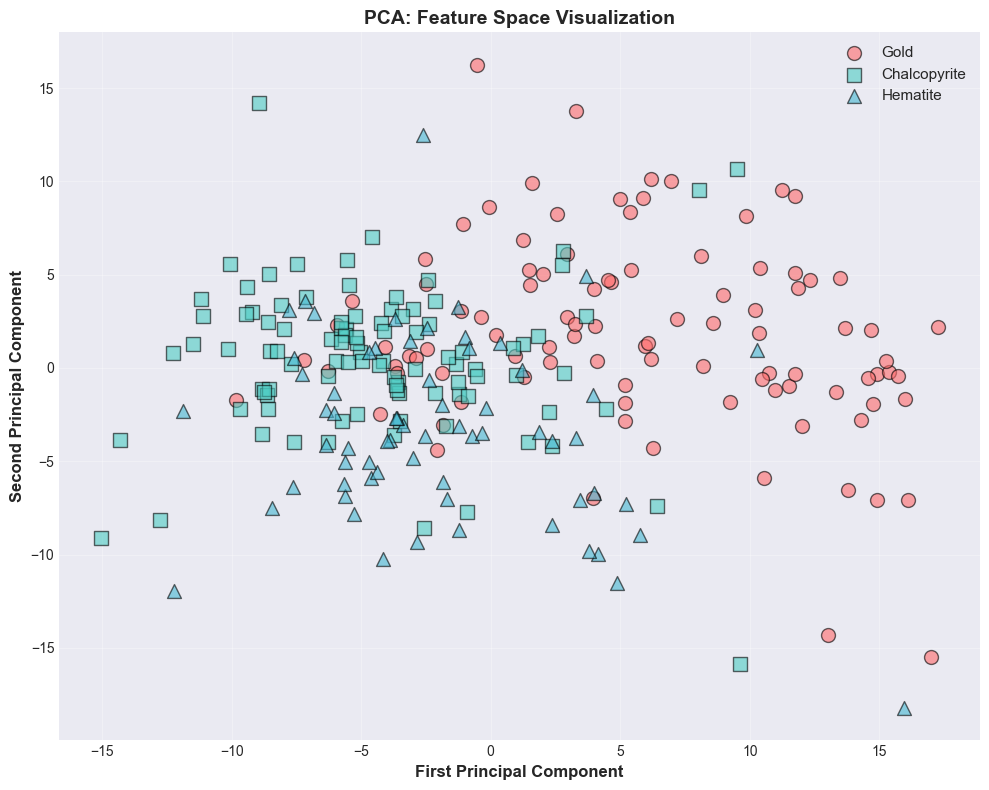


📊 PCA Explained Variance:
   PC1: 46.32%
   PC2: 23.42%
   Total: 69.75%


In [18]:
# Apply PCA
pca = PCA(n_components=2)
embeddings_pca = pca.fit_transform(embeddings)

# Plot
plt.figure(figsize=(10, 8))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
markers = ['o', 's', '^']

for i, (name, color, marker) in enumerate(zip(class_names, colors, markers)):
    mask = labels == i
    plt.scatter(embeddings_pca[mask, 0], embeddings_pca[mask, 1], 
                c=color, label=name, alpha=0.6, s=100, marker=marker, edgecolors='black')

plt.xlabel('First Principal Component', fontsize=12, fontweight='bold')
plt.ylabel('Second Principal Component', fontsize=12, fontweight='bold')
plt.title('PCA: Feature Space Visualization', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📊 PCA Explained Variance:")
print(f"   PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"   PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"   Total: {sum(pca.explained_variance_ratio_)*100:.2f}%")

### 12.3 t-SNE Visualization

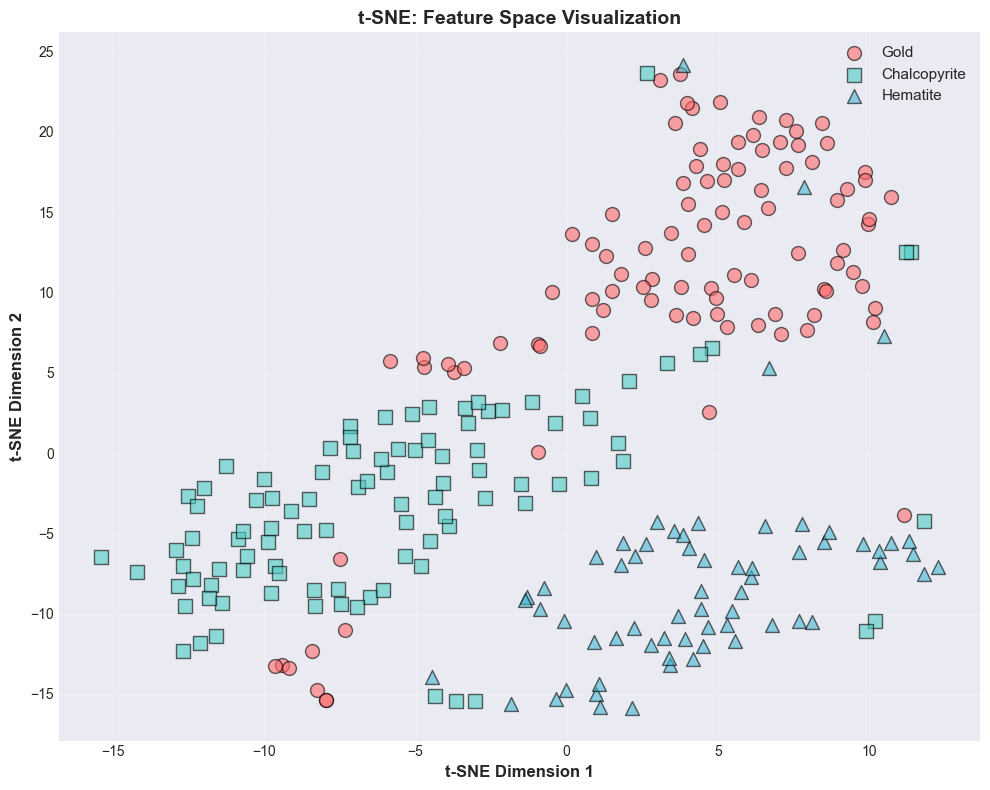


✅ t-SNE visualization shows how well the model separates different mineral classes!


In [19]:
# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_tsne = tsne.fit_transform(embeddings)

# Plot
plt.figure(figsize=(10, 8))

for i, (name, color, marker) in enumerate(zip(class_names, colors, markers)):
    mask = labels == i
    plt.scatter(embeddings_tsne[mask, 0], embeddings_tsne[mask, 1], 
                c=color, label=name, alpha=0.6, s=100, marker=marker, edgecolors='black')

plt.xlabel('t-SNE Dimension 1', fontsize=12, fontweight='bold')
plt.ylabel('t-SNE Dimension 2', fontsize=12, fontweight='bold')
plt.title('t-SNE: Feature Space Visualization', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ t-SNE visualization shows how well the model separates different mineral classes!")